Analyzing images: 100%|██████████| 100/100 [00:01<00:00, 56.12it/s]


✅ Saved metrics to processing_metrics.csv


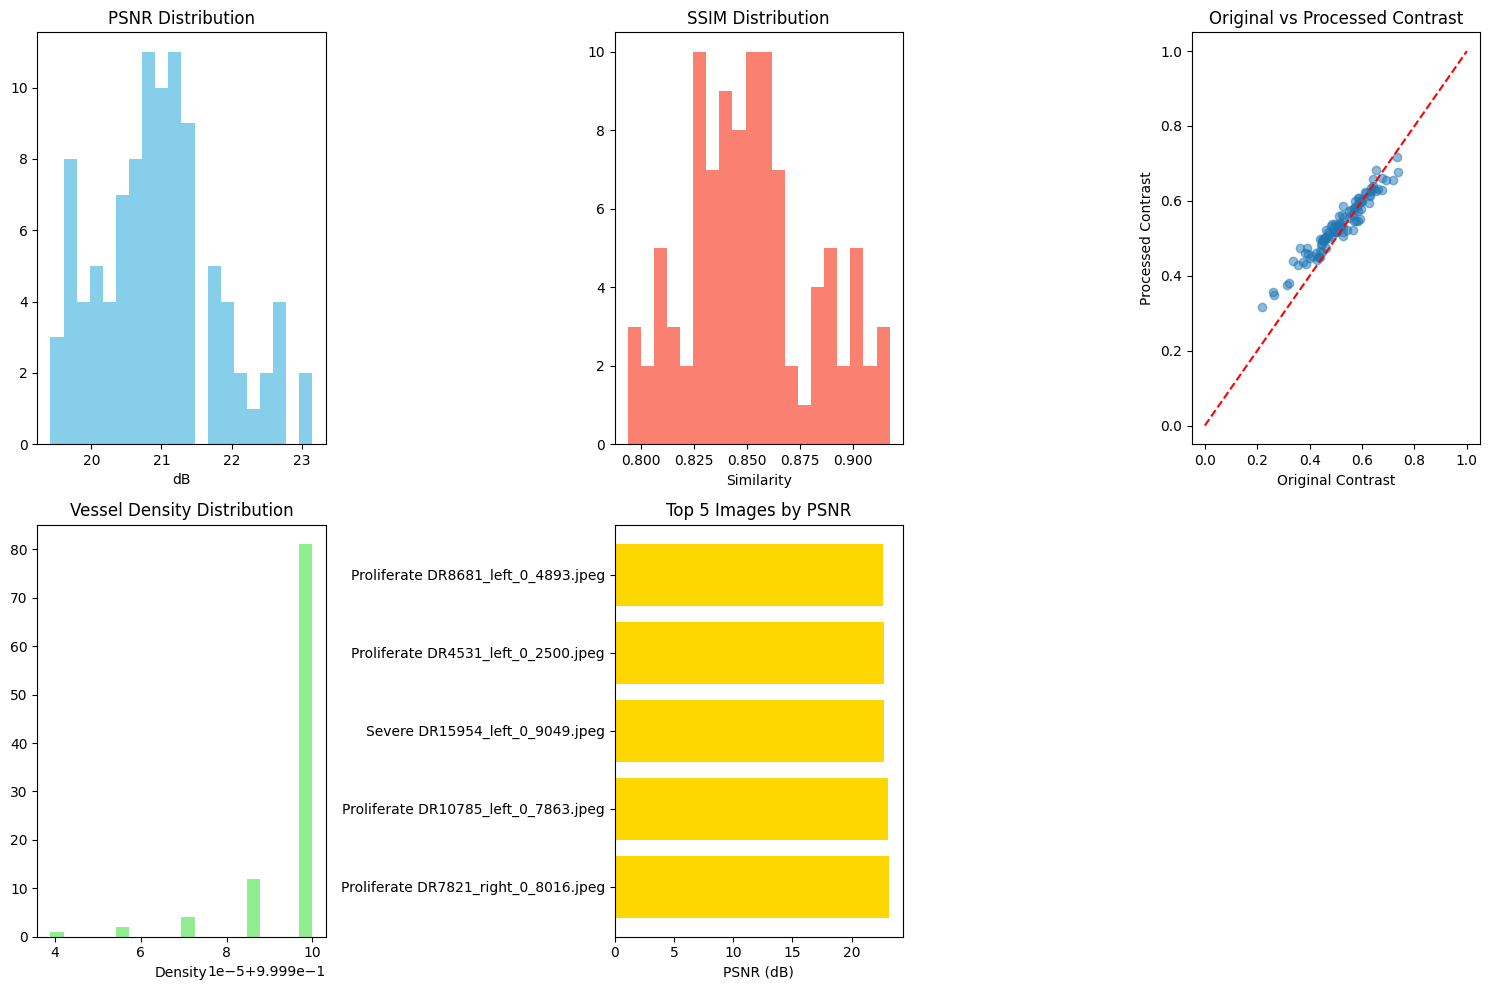


📊 Statistical Summary:
              mse        psnr        ssim  contrast_orig  contrast_proc  \
count  100.000000  100.000000  100.000000     100.000000     100.000000   
mean   532.667902   20.945741    0.851874       0.515837       0.535957   
std    100.218704    0.847372    0.029880       0.105369       0.077588   
min    314.744095   19.417801    0.793768       0.216983       0.317547   
25%    475.059422   20.390222    0.831387       0.447293       0.490603   
50%    527.519768   20.908417    0.849801       0.518838       0.533283   
75%    594.377499   21.363328    0.867456       0.588308       0.595255   
max    743.533005   23.151228    0.917465       0.737125       0.717304   

       vessel_density  
count      100.000000  
mean         0.999995  
std          0.000011  
min          0.999939  
25%          1.000000  
50%          1.000000  
75%          1.000000  
max          1.000000  


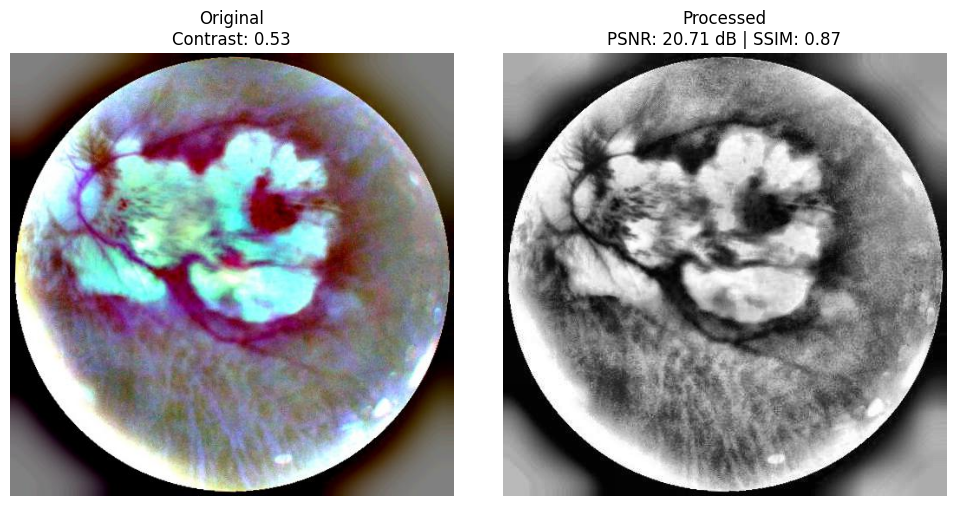

In [3]:
# %% [markdown]
# # Retinal Image Quality Metrics
# Companion notebook for try_1.ipynb - Calculates processing quality metrics

# %%
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from tqdm import tqdm
import os

# %% [markdown]
# ## 1. Configuration (Match Your Paths)
# %%
ORIGINAL_PATH = r"C:\Users\mgree\Downloads\CV_BINARY_DATASET\CVD_Positive" 
PROCESSED_PATH = r"C:\Users\mgree\Downloads\Processed_CV_DATASET\Enhanced\CVD_Positive"
OUTPUT_CSV = "processing_metrics.csv"
SAMPLE_SIZE = 100  # Number of images to analyze

# %% [markdown]
# ## 2. Metric Calculation Functions
# %%
class ImageMetrics:
    @staticmethod
    def mse(imageA, imageB):
        err = np.mean((imageA.astype("float") - imageB.astype("float")) ** 2)
        return err
    
    @staticmethod
    def psnr(imageA, imageB):
        mse = ImageMetrics.mse(imageA, imageB)
        if mse == 0:
            return 100
        return 20 * np.log10(255.0 / np.sqrt(mse))
    
    @staticmethod
    def contrast(image):
        return np.std(image) / np.mean(image)
    
    @staticmethod
    def vessel_density(vessel_mask):
        return np.sum(vessel_mask > 0) / vessel_mask.size

# %% [markdown]
# ## 3. Batch Processing
# %%
def analyze_processing_quality():
    # Get paired images
    original_images = [f for f in os.listdir(ORIGINAL_PATH) if f.endswith(('.jpg','.jpeg','.png'))]
    processed_images = [f for f in os.listdir(PROCESSED_PATH) if f.endswith(('.jpg','.jpeg','.png'))]
    
    common_images = list(set(original_images) & set(processed_images))[:SAMPLE_SIZE]
    results = []
    
    for img_name in tqdm(common_images, desc="Analyzing images"):
        try:
            # Load images
            orig = cv2.imread(os.path.join(ORIGINAL_PATH, img_name), cv2.IMREAD_GRAYSCALE)
            proc = cv2.imread(os.path.join(PROCESSED_PATH, img_name), cv2.IMREAD_GRAYSCALE)
            
            if orig is None or proc is None:
                continue
                
            # Resize to match dimensions
            orig = cv2.resize(orig, (256, 256))
            proc = cv2.resize(proc, (256, 256))
            
            # Calculate metrics
            metrics = {
                'image': img_name,
                'mse': ImageMetrics.mse(orig, proc),
                'psnr': ImageMetrics.psnr(orig, proc),
                'ssim': ssim(orig, proc, data_range=proc.max()-proc.min()),
                'contrast_orig': ImageMetrics.contrast(orig),
                'contrast_proc': ImageMetrics.contrast(proc),
                'vessel_density': ImageMetrics.vessel_density(proc)
            }
            results.append(metrics)
            
        except Exception as e:
            print(f"Error processing {img_name}: {str(e)}")
    
    return pd.DataFrame(results)

# %% [markdown]
# ## 4. Run Analysis
# %%
metrics_df = analyze_processing_quality()
metrics_df.to_csv(OUTPUT_CSV, index=False)
print(f"✅ Saved metrics to {OUTPUT_CSV}")

# %% [markdown]
# ## 5. Visualization
# %%
def plot_metrics(df):
    plt.figure(figsize=(15, 10))
    
    # PSNR Distribution
    plt.subplot(2, 3, 1)
    plt.hist(df['psnr'], bins=20, color='skyblue')
    plt.title('PSNR Distribution')
    plt.xlabel('dB')
    
    # SSIM Distribution
    plt.subplot(2, 3, 2)
    plt.hist(df['ssim'], bins=20, color='salmon')
    plt.title('SSIM Distribution')
    plt.xlabel('Similarity')
    
    # Contrast Comparison
    plt.subplot(2, 3, 3)
    plt.scatter(df['contrast_orig'], df['contrast_proc'], alpha=0.5)
    plt.plot([0,1],[0,1], 'r--')
    plt.title('Original vs Processed Contrast')
    plt.xlabel('Original Contrast')
    plt.ylabel('Processed Contrast')
    
    # Vessel Density
    plt.subplot(2, 3, 4)
    plt.hist(df['vessel_density'], bins=20, color='lightgreen')
    plt.title('Vessel Density Distribution')
    plt.xlabel('Density')
    
    # Top 5 Images by PSNR
    plt.subplot(2, 3, 5)
    top_psnr = df.nlargest(5, 'psnr')
    plt.barh(top_psnr['image'], top_psnr['psnr'], color='gold')
    plt.title('Top 5 Images by PSNR')
    plt.xlabel('PSNR (dB)')
    
    plt.tight_layout()
    plt.savefig('quality_metrics_visualization.png')
    plt.show()

plot_metrics(metrics_df)

# %% [markdown]
# ## 6. Statistical Summary
# %%
print("\n📊 Statistical Summary:")
print(metrics_df.describe())

# %% [markdown]
# ## 7. Sample Image Comparison
# %%
def display_sample_comparison(df):
    sample = df.sample(1).iloc[0]
    
    orig_img = cv2.imread(os.path.join(ORIGINAL_PATH, sample['image']))
    proc_img = cv2.imread(os.path.join(PROCESSED_PATH, sample['image']))
    
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Original\nContrast: {sample['contrast_orig']:.2f}")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(proc_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Processed\nPSNR: {sample['psnr']:.2f} dB | SSIM: {sample['ssim']:.2f}")
    plt.axis('off')
    
    plt.tight_layout()
    plt.savefig('sample_comparison.png')
    plt.show()

display_sample_comparison(metrics_df)

In [2]:
! pip install tqdm

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
